# Fehlerverhalten und Runge-Kutta Verfahren höherer Ordnung
## Fehlerverhalten

Wir haben festgestellt, dass in *einem Schritt* der Länge $h$ die Eulerverfahren die Taylorentwicklung erster Ordnung korrekt wiedergeben. Für das explizite Eulerverfahren:

$$
    y_{k+1} = y_k + h \cdot f(x_{k}, y_{k}) = y_k + h \cdot y'(x_k)
$$

Dies bedeutet, dass der Fehler *pro Schritt* etwa proportional zu $h^2$ ist. Wird $h$ halbiert, so wird der Fehler pro Schritt also etwa um einen Faktor $4$ kleiner. Da man dafür doppelt so viele Schritte machen muss, wird der Fehler über ein Intervall $[x_0, x_n]$ wiederum etwa halbiert.

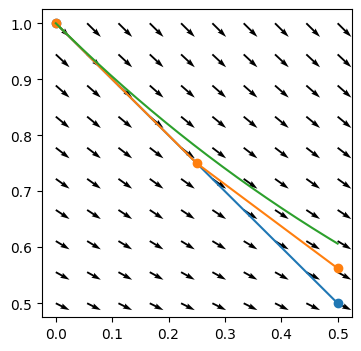

In [12]:
import numpy as np 
import matplotlib.pyplot as plt 

f   = lambda x, y :  - y # y' = -y

# Darstellung des Vektorfeldes
u = lambda x, y: np.ones(x.shape)    # für Darstellung des Vektorfeldes: x' = 1
v = lambda x, y: f(x,y)              # ebenso y' = f(x, y)
x, y = np.linspace(0, .5, 10), np.linspace(0.5,1,10)
X, Y = np.meshgrid(x,y)

plt.figure(figsize = (4, 4))
plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .5)

y0 = 1
x0 = 0

h = .5

# Schrittweite h (Euler vorwärts)
y1 = y0 + h * f(x0, y0)

#Schrittweite h/2 (Euler vorwärts)
y12 = y0 +  h/2 * f(x0,     y0)
y22 = y12 + h/2 * f(x0+h/2, y12)

plt.plot([x0, x0+h], [y0, y1], "o-")
plt.plot([x0, x0+h/2, x0+h], [y0, y12, y22], "o-")

xx = np.linspace(x[0], x[0]+h, 500)
plt.plot(xx, np.exp(-xx))


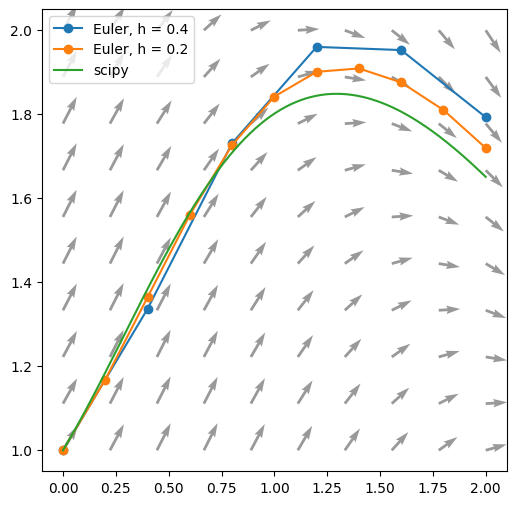

In [2]:
f   = lambda x, y :  np.sin(x+y)  # y' = f(x, y)
d2f = lambda x, y :  np.cos(x+y)  # partielle Ableitung df / dy. Wird für die implizite Eulermethode verwendet

# Darstellung des Vektorfeldes
u = lambda x, y: np.ones(x.shape)    # für Darstellung des Vektorfeldes: x' = 1
v = lambda x, y: f(x,y)              # ebenso y' = f(x, y)

x, y = np.linspace(0, 2,10), np.linspace(1,2,10)

X, Y = np.meshgrid(x,y)


#%% Euler (vorwärts) Achtung: es ist nicht garantiert, dass die Endstelle xn exakt getroffen wird!
def eulerExplizit(f, x0, y0, xn, h):
    
    x = [x0]
    y = [y0]
    
    while x[-1] < xn-h/2:        
        y.append(y[-1] + h * f(x[-1], y[-1]) )
        x.append(x[-1] + h)
    return np.array(x), np.array(y)
 
y0 = 1
x0 = x[0]

x1, y1 = eulerExplizit(f = f, x0 = x0, y0 = y0, xn = x[-1], h = .4)
x2, y2 = eulerExplizit(f = f, x0 = x0, y0 = y0, xn = x[-1], h = .2)

from scipy.integrate import solve_ivp 
sol = solve_ivp(f, [x0, x[-1]], [y0], t_eval= np.linspace(x[0],x[-1], 500))
x3, y3 = sol.t, sol.y[0]

plt.figure(figsize = (6, 6))
plt.plot(x1, y1, 'o-', label = "Euler, h = 0.4")
plt.plot(x2, y2, 'o-', label = "Euler, h = 0.2")
plt.plot(x3, y3, '-', label = "scipy")
plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .25, color = [.6,.6,.6])
plt.legend()

## Verfahren höherer Ordnung
Für ein Verfahren der Ordnung $p$ liegt der Näherungswert $y_{k+1}$ auf dem Taylorpolynom der Ordnung $p$ der Lösung durch $(x_k, y_k)$.

$$
    y_{k+1} = y_k + h \cdot y'(x_k) + \frac{h^2}{2} \cdot y''(x_k) + \ldots + \frac{h^p}{p!} \cdot y^{(p)}(x_k) \approx y(x_k + h)
$$

**Dies führt zum folgenden qualitativen Fehlerverhalten**: 

Wird die Schrittweite halbiert, so skaliert der Fehler pro Schritt mit

$$
    \eta \to \eta \cdot \left( \frac{1}{2} \right)^{p+1}
$$

und der resultierende Gesamtfehler mit 

$$
    e \to e \cdot 2 \cdot \left( \frac{1}{2} \right)^{p+1} = \left( \frac{1}{2} \right)^{p} 
$$

weil ja jetzt doppelt so viele Schritte benötigt werden. Das ist eine **Faustregel**, da Fehler höherer Ordnung in der Taylorreihe, sämtliche Koeffizienten sowie Instabilitäten etc. nicht berücksichtigt sind.

### Die Fehlerordnung der Mittelpunktsregel ist $p = 2$ 
Es gilt nämlich
\begin{eqnarray*}
    y'(x_k)  &=& f(x_k, y_k) \\[.5em]
    y''(x_k) &=& f_{.x}(x_k, y_k) + f_{.y}(x_k, y_k) \cdot y'(x_k) = f_{.x}(x_k, y_k) + f_{.y}(x_k, y_k) \cdot f(x_k, y_k)  
\end{eqnarray*}

also gilt für die **Taylorentwicklung**

\begin{eqnarray*}
    y(x_k + h) = y(x_k) + h \cdot f(x_k, y_k) + \frac{h^2}{2} \cdot \left( f_{.x}(x_k, y_k) + f_{.y}(x_k, y_k) \cdot f(x_k, y_k) \right) + O(h^3)
\end{eqnarray*}

Die **Mittelpunktsmethode** liefert 

\begin{eqnarray*}
    r_1 &=& {\color{blue} f(x_k, y_k)} \\[.5em]
    r_2 &=& f(x_k + h/2, y_k + h/2 \cdot r_1) \approx f(x_k, y_k) + \frac{h}{2} \cdot \left( f_{.x}(x_k, y_k) + f_{.y}(x_k, y_k) \cdot {\color{blue} f(x_k, y_k)} \right) + O(h^2) \\[1em]
    y_{k+1} &=& y_{k} + h \cdot r_2 = y_{k} + h \cdot \Big[f(x_k, y_k) + \frac{h}{2} \cdot \left( f_{.x}(x_k, y_k) + f_{.y}(x_k, y_k) \cdot f(x_k, y_k) \right) \Big] + O(h^3)
\end{eqnarray*}

Wir erwarten also, dass der Fehler pro Schritt bei halber Schrittweite mit $1/8$ skaliert wird, und der Gesamtfehler mit $1/4$.

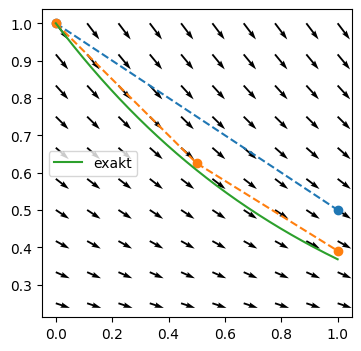

In [11]:
f   = lambda x, y :  - y # y' = -y
h = 1.
# Darstellung des Vektorfeldes
u = lambda x, y: np.ones(x.shape)    # für Darstellung des Vektorfeldes: x' = 1
v = lambda x, y: f(x,y)              # ebenso y' = f(x, y)
x, y = np.linspace(0, h, 10), np.linspace(0.25,1,10)
X, Y = np.meshgrid(x,y)

plt.figure(figsize = (4, 4))
plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .5)

y0 = 1
x0 = 0

def midOneStep(f, x, y, h):
    r1 = f(x, y)
    r2 = f(x+h/2, y+ h/2 * r1)
    return y + h * r2

# Schrittweite h (Mittelpunktsmethode)
y1 = midOneStep(f, x0, y0, h)

#Schrittweite h/2 (Mittelpunktsmethode)
y12 = midOneStep(f, x0, y0, h/2)
y22 = midOneStep(f, x0 + h/2, y12, h/2)

plt.plot([x0, x0+h], [y0, y1], "o--")
plt.plot([x0, x0+h/2, x0+h], [y0, y12, y22], "o--")

xx = np.linspace(x[0], x[0]+h, 500)
plt.plot(xx, np.exp(-xx), label = "exakt")
plt.legend()


### Butcher-Tableaus

Runge-Kutta Verfahren höherer Ordnung lassen sich durch ihr **Butcher-Tableau** beschreiben.

Ein Beispiel mit Fehlerordnung $p = 4$ ist das **klassische Runge Kutta Verfahren 4. Ordnung**

In [15]:
def rk4(f, x0, y0, xn, h):
    x = [x0]
    y = [y0]
    while x[-1] < xn - h/2:
        r1 = f(x[-1], y[-1])
        r2 = f(x[-1] + h/2, y[-1] + h/2 * r1)
        r3 = f(x[-1] + h/2, y[-1] + h/2 * r2)
        r4 = f(x[-1] + h , y[-1] + h * r3)
        y.append(y[-1] + h/6 * (r1 + 2*r2 + 2*r3 + r4))
        x.append(x[-1] + h)
    return x, y

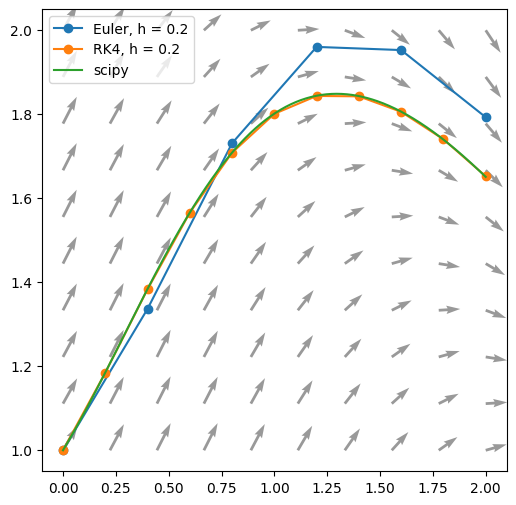

In [16]:
f   = lambda x, y :  np.sin(x+y)  # y' = f(x, y)
d2f = lambda x, y :  np.cos(x+y)  # partielle Ableitung df / dy. Wird für die implizite Eulermethode verwendet

# Darstellung des Vektorfeldes
u = lambda x, y: np.ones(x.shape)    # für Darstellung des Vektorfeldes: x' = 1
v = lambda x, y: f(x,y)              # ebenso y' = f(x, y)

x, y = np.linspace(0, 2,10), np.linspace(1,2,10)

X, Y = np.meshgrid(x,y)

x0 = 0
y0 = 1
xrk4, yrk4 = rk4(f, x0, y0, x[-1], 0.2)

plt.figure(figsize = (6, 6))
plt.plot(x1, y1, 'o-', label = "Euler, h = 0.2")
plt.plot(xrk4, yrk4, 'o-', label = "RK4, h = 0.2")
plt.plot(x3, y3, '-', label = "scipy")
plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .25, color = [.6,.6,.6])
plt.legend()


## Fehlerordnung
Wenn man **einen Schritt** des jeweiligen Verfahrens durchführt, so folgt 

 * Euler der Tangente (= Taylor erster Ordnung) der Lösungskurve, das bedeutet **Fehlerordnung 1**
 * RK4 der Taylorentwicklung vierter Ordnung (bis $h^4$) der Lösungskurve, hat also **Fehlerordnung 4**

Die Koeffizienten im Schema von RK4 sind so bestimmt, dass diese Fehlerordnung erreicht wird. 

(1.0, 2.25)

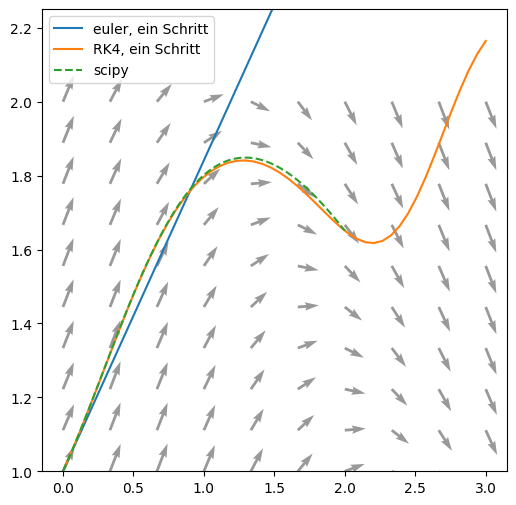

In [19]:
def rk4Step(f, x, y, h):
    r1 = f(x, y)
    r2 = f(x + h/2, y + h/2 * r1)
    r3 = f(x + h/2, y + h/2 * r2)
    r4 = f(x + h  , y + h   * r3)
    
    return y + h/6 * (r1 + 2*r2 + 2*r3 + r4)

def eulerStep(f, x, y, h):
    return y + h * f(x, y)

f   = lambda x, y :  np.sin(x+y)  # y' = f(x, y)

x0 = 0
y0 = 1
hs = np.linspace(0.01, 3, 50)
yeOneStep = eulerStep(f, x0, y0, hs)
yrkOneStep = rk4Step(f, x0, y0, hs)
yhOneStep = heunStep(f, x0, y0, hs)

x, y = np.linspace(0, 3,10), np.linspace(1,2,10)
X, Y = np.meshgrid(x,y)

xrk4, yrk4 = rk4(f, x0, y0, x[-1], 0.05)

plt.figure(figsize = (6, 6))
plt.plot(x0+hs, yeOneStep, label = "euler, ein Schritt")
plt.plot(x0+hs, yrkOneStep, label = "RK4, ein Schritt")
plt.plot(x3, y3, '--', label = "scipy")

plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .25, color = [.6,.6,.6])
plt.legend()
plt.ylim([1,2.25])


## Stabilität
Trotz erhöhter Genauigkeit für $h \to 0$ wird die oben definierte klassische Runge-Kutta Methode (RK4) (ebenso wie die explizite Eulermethode) für grosse $h$ unbrauchbar. Am Beispiel $y' = -y$ etwa für $h \geq 2.5$ 

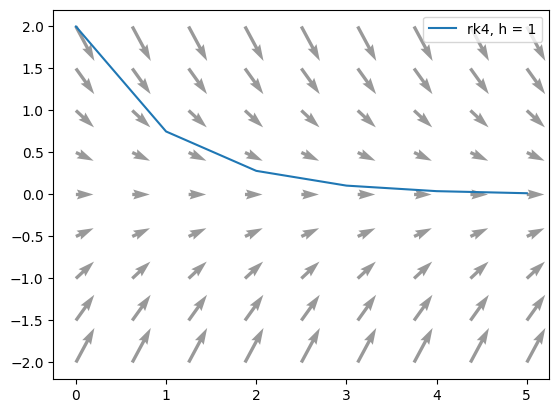

In [28]:
a = 1

x, y = np.linspace(0, np.max((5, 5*h)),9), np.linspace(-2, 2,9)
X, Y = np.meshgrid(x,y)
plt.quiver(X, Y, np.ones_like(X), - a * Y, angles = "xy", color = [.6,.6,.6])

y0 = 2
h = 1
xrk4, yrk4 = rk4(f = lambda x,y:-y, x0 = 0, y0 = 2, xn = x[-1], h = h)

plt.plot(xrk4, yrk4, label = "rk4, h = {:g}".format(h))
plt.legend()